In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense

In [2]:
X = np.random.rand(1000, 10, 1)
y = np.sum(X, axis=1)

In [3]:
def build_model(model_type):
    model = Sequential()

    if model_type == "RNN":
        model.add(SimpleRNN(32, input_shape=(10, 1)))
    elif model_type == "LSTM":
        model.add(LSTM(32, input_shape=(10, 1)))
    elif model_type == "GRU":
        model.add(GRU(32, input_shape=(10, 1)))

    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

In [4]:
results = {}

for m in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {m}...")
    model = build_model(m)

    start = time.time()
    history = model.fit(X, y, epochs=5, batch_size=32, verbose=0)
    end = time.time()

    results[m] = {
        "loss": history.history['loss'],
        "time": end - start
    }

    print(f"{m} Final Loss:", history.history['loss'][-1])
    print(f"{m} Time:", round(end-start,2), "sec")


Training RNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


RNN Final Loss: 0.7962132096290588
RNN Time: 1.98 sec

Training LSTM...
LSTM Final Loss: 0.4865604341030121
LSTM Time: 2.29 sec

Training GRU...
GRU Final Loss: 0.6068775653839111
GRU Time: 3.21 sec


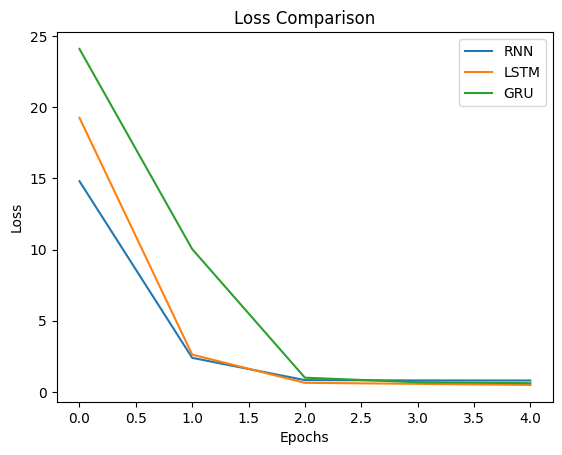

In [5]:
for m in results:
    plt.plot(results[m]["loss"], label=m)

plt.title("Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()